# 2 · Learning what physics misses (hybrid dynamics + system ID)

A domain expert can write down *most* of a system — an RC thermal balance, an orbital force model, a
compartmental epidemic — but never *all* of it. `chc` models
$$\dot x = \underbrace{f_{\text{known}}(x,u)}_{\text{mechanism}} + \underbrace{r_\theta(x,u)}_{\text{learned residual}}$$
and trains **only the residual**, leaving the known physics intact. This needs far less data than a
black box, extrapolates better, and keeps the learned part small and interpretable.

Here the *true* plant is a damped oscillator **plus a hidden cubic stiffening term**. The known model
omits the cubic; we recover it from data.

In [1]:
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pandas as pd

jax.config.update("jax_enable_x64", True)
%matplotlib inline

from chc import (
    DampedOscillator,
    HybridDynamics,
    KANResidual,
    MLPResidual,
    ZeroResidual,
    fit_residual,
    fit_residual_multistep,
    one_step_mse,
    rk4_step,
    rollout,
)

DT = 0.05


class CubicResidual(eqx.Module):
    """The hidden physics the known model omits: a cubic stiffening force."""

    beta: float

    def __call__(self, t, x, u):
        return jnp.array([0.0, -self.beta * x[0] ** 3])


known = DampedOscillator(omega=1.0, zeta=0.1)
true_plant = HybridDynamics(known=known, residual=CubicResidual(beta=0.5))

## Generate noisy one-step transitions from the true plant

In [2]:
k_x, k_u = jax.random.split(jax.random.key(0))
xs = jax.random.normal(k_x, (2000, 2))
us = 0.5 * jax.random.normal(k_u, (2000, 1))
x_next = jax.vmap(lambda x, u: rk4_step(true_plant, 0.0, x, u, DT))(xs, us)
data = {"x": xs, "u": us, "x_next": x_next}

known_only = HybridDynamics(known=known, residual=ZeroResidual(out_dim=2))
mse_known = float(one_step_mse(known_only, xs, us, x_next, DT))
print(f"known-only one-step MSE = {mse_known:.4e}  (the residual it ignores)")

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


known-only one-step MSE = 5.2612e-03  (the residual it ignores)


## Fit a residual — MLP and interpretable RBF-KAN backends

The residual is a swappable *Strategy*: the same training / adjoint machinery works for an MLP, an
RBF-KAN (interpretable edges), a linear term, etc.

In [3]:
rows = [("known-only (r=0)", mse_known)]
trained = {}
for name, residual in [
    ("MLP residual", MLPResidual(2, 1, 2, width=32, key=jax.random.key(1))),
    ("KAN residual", KANResidual(2, 1, 2, num_grid=12, grid_range=4.0, key=jax.random.key(2))),
]:
    model, _ = fit_residual(HybridDynamics(known=known, residual=residual), data, DT, steps=2000)
    trained[name] = model
    rows.append((name, float(one_step_mse(model, xs, us, x_next, DT))))

table = pd.DataFrame(rows, columns=["model", "one-step MSE"]).set_index("model")
table["vs known-only"] = (table["one-step MSE"] / mse_known).map(lambda v: f"{v:.1%}")
table

,one-step MSE,vs known-only
model,,
known-only (r=0),5.261207e-03,100.0%
MLP residual,2.253294e-07,0.0%
KAN residual,3.153087e-05,0.6%


Both learned residuals cut the one-step error by **>5×** — the hybrid model recovers the physics the
known model omits.

## The learned residual matches the true hidden physics

Because the residual is a small function of `x`, we can *plot it against the ground truth* — it learned
the cubic, not a black-box blob.

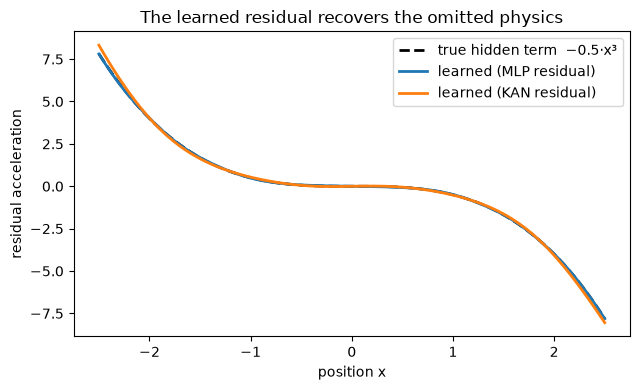

In [4]:
grid = jnp.linspace(-2.5, 2.5, 100)
u0 = jnp.zeros(1)
true_curve = jax.vmap(lambda p: CubicResidual(0.5)(0.0, jnp.array([p, 0.0]), u0)[1])(grid)
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(grid, true_curve, "k--", lw=2, label="true hidden term  −0.5·x³")
for name, model in trained.items():
    learned = jax.vmap(lambda p: model.residual(0.0, jnp.array([p, 0.0]), u0)[1])(grid)
    ax.plot(grid, learned, lw=2, label=f"learned ({name})")
ax.set_xlabel("position x")
ax.set_ylabel("residual acceleration")
ax.set_title("The learned residual recovers the omitted physics")
ax.legend()
plt.tight_layout()
plt.show()

## Multi-step training cuts long-horizon drift

One-step (teacher-forced) fitting minimises local error but lets mistakes *compound* over a rollout.
`fit_residual_multistep` optimises the multi-step rollout directly.

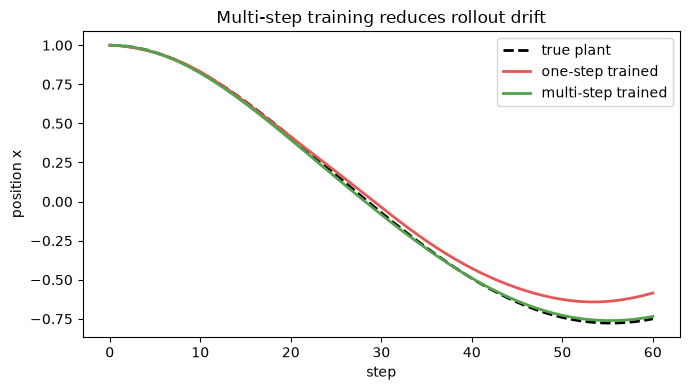

one-step  rollout error = 5.25e-03
multi-step rollout error = 1.37e-04


In [5]:
horizon, n_traj = 15, 300
k0, k1, k2 = jax.random.split(jax.random.key(3), 3)
x0s = 0.8 * jax.random.normal(k0, (n_traj, 2))
u_seq = 0.3 * jax.random.normal(k1, (n_traj, horizon, 1))
xs_clean = jax.vmap(lambda x0, u: rollout(true_plant, x0, u, DT))(x0s, u_seq)
xs_noisy = xs_clean + 0.02 * jax.random.normal(k2, xs_clean.shape)


def fresh():
    return HybridDynamics(known=known, residual=MLPResidual(2, 1, 2, width=32, key=jax.random.key(1)))


m_one, _ = fit_residual(
    fresh(),
    {"x": xs_noisy[:, :-1].reshape(-1, 2), "u": u_seq.reshape(-1, 1), "x_next": xs_noisy[:, 1:].reshape(-1, 2)},
    DT,
    steps=1500,
)
m_multi, _ = fit_residual_multistep(
    fresh(), {"x0": xs_noisy[:, 0], "us": u_seq, "xs": xs_noisy}, DT, steps=1500
)

# evaluate a long rollout from a fixed start
x0 = jnp.array([1.0, 0.0])
ctrl = jnp.zeros((60, 1))
truth = rollout(true_plant, x0, ctrl, DT)[:, 0]
roll_one = rollout(m_one, x0, ctrl, DT)[:, 0]
roll_multi = rollout(m_multi, x0, ctrl, DT)[:, 0]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(truth, "k--", lw=2, label="true plant")
ax.plot(roll_one, lw=2, color="#E45756", label="one-step trained")
ax.plot(roll_multi, lw=2, color="#54A24B", label="multi-step trained")
ax.set_xlabel("step")
ax.set_ylabel("position x")
ax.set_title("Multi-step training reduces rollout drift")
ax.legend()
plt.tight_layout()
plt.show()

print(f"one-step  rollout error = {float(jnp.mean((roll_one - truth) ** 2)):.2e}")
print(f"multi-step rollout error = {float(jnp.mean((roll_multi - truth) ** 2)):.2e}")

### Takeaway
Don't re-learn the physics you already know. `chc` learns a small, interpretable residual for the
unknown part — cutting one-step error >5× — and multi-step training keeps long rollouts on track.